
=== Trie | n = 1000 ===
Inserción      -> media: 3.835 ms | std: 1.142
Búsqueda exacta-> media: 1.130 ms | std: 0.515
Búsqueda pref. -> media: 0.299 ms | std: 0.072
Memoria actual -> 1.553 MB
Memoria pico   -> 1.553 MB

=== Trie | n = 10000 ===
Inserción      -> media: 35.765 ms | std: 7.483
Búsqueda exacta-> media: 2.132 ms | std: 0.433
Búsqueda pref. -> media: 0.495 ms | std: 0.228
Memoria actual -> 13.609 MB
Memoria pico   -> 13.609 MB

=== Trie | n = 100000 ===
Inserción      -> media: 5529.860 ms | std: 22788.246
Búsqueda exacta-> media: 2.314 ms | std: 0.354
Búsqueda pref. -> media: 0.508 ms | std: 0.085
Memoria actual -> 118.190 MB
Memoria pico   -> 118.190 MB

=== HashTable | n = 1000 ===
Inserción      -> media: 0.078 ms | std: 0.012
Búsqueda exacta-> media: 0.056 ms | std: 0.007
Búsqueda pref. -> media: 12.589 ms | std: 1.283
Memoria actual -> 0.033 MB
Memoria pico   -> 0.042 MB

=== HashTable | n = 10000 ===
Inserción      -> media: 1.163 ms | std: 0.621
Búsqueda exacta-> m

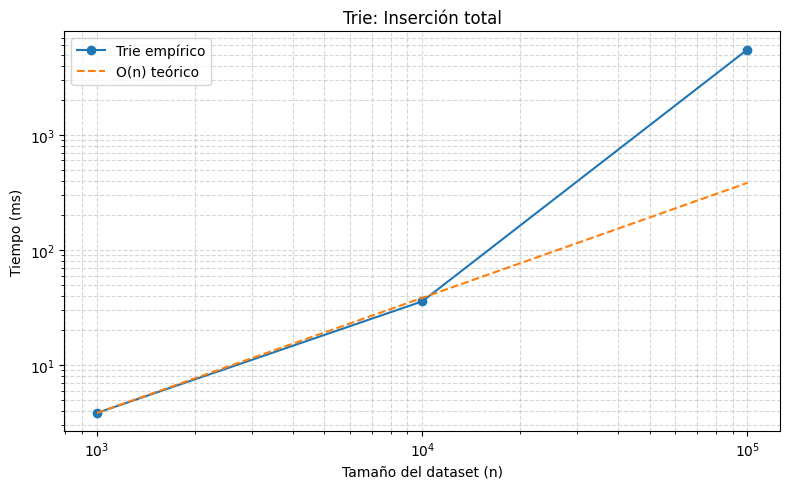

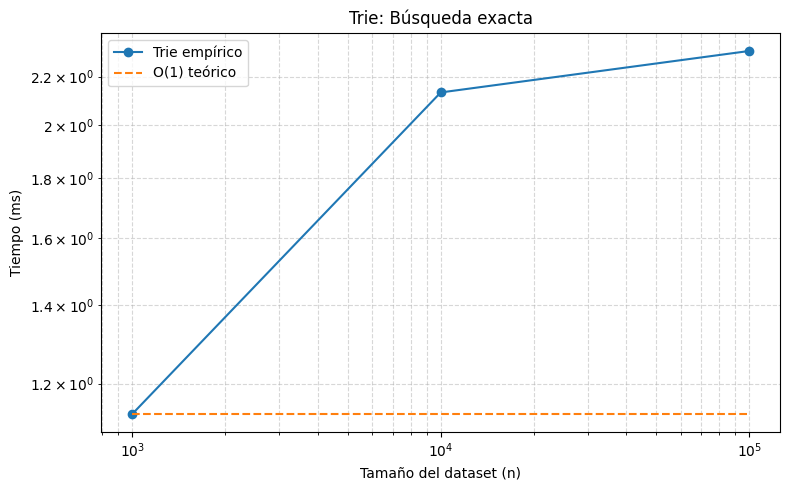

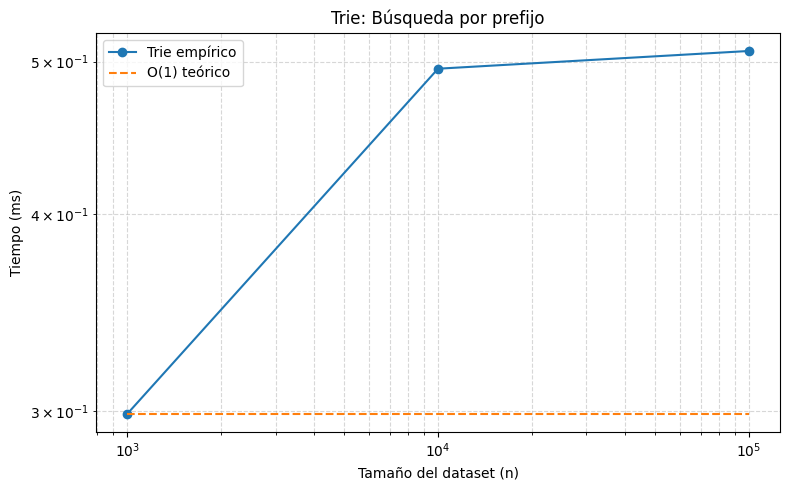

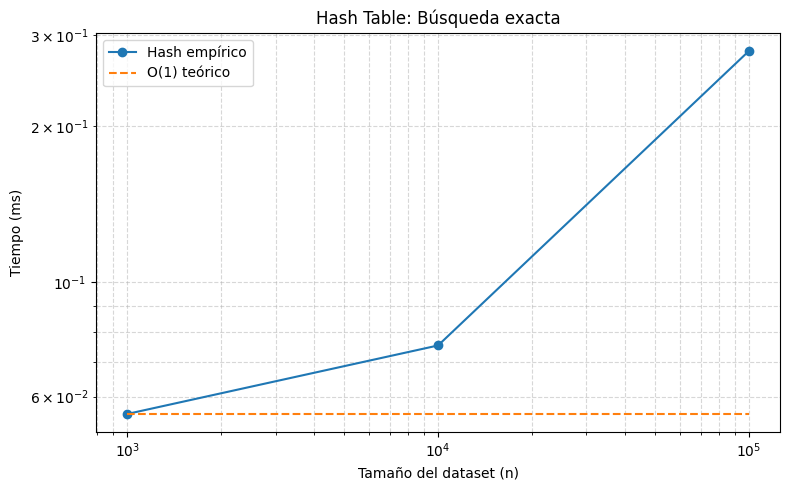

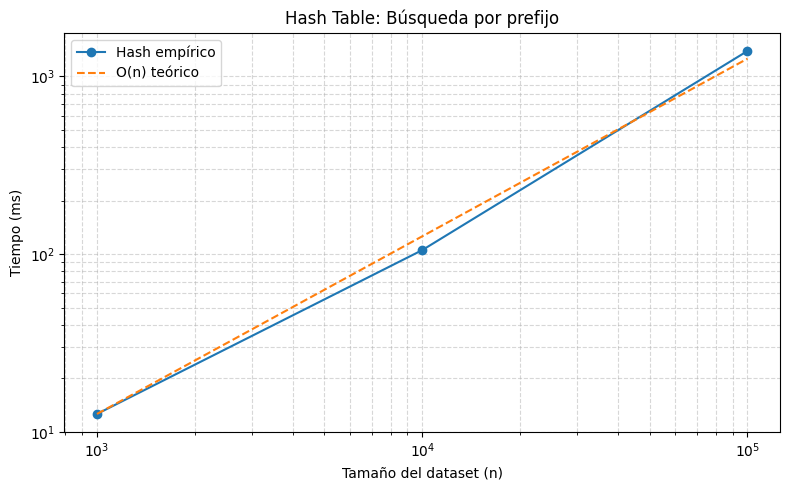

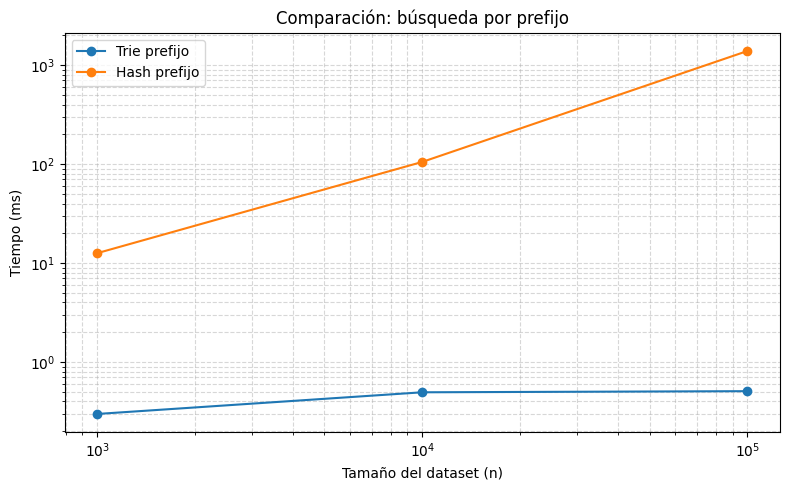

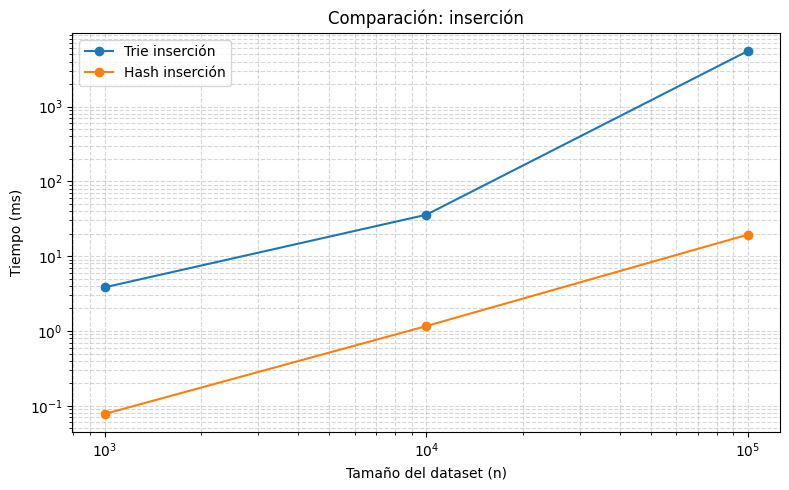

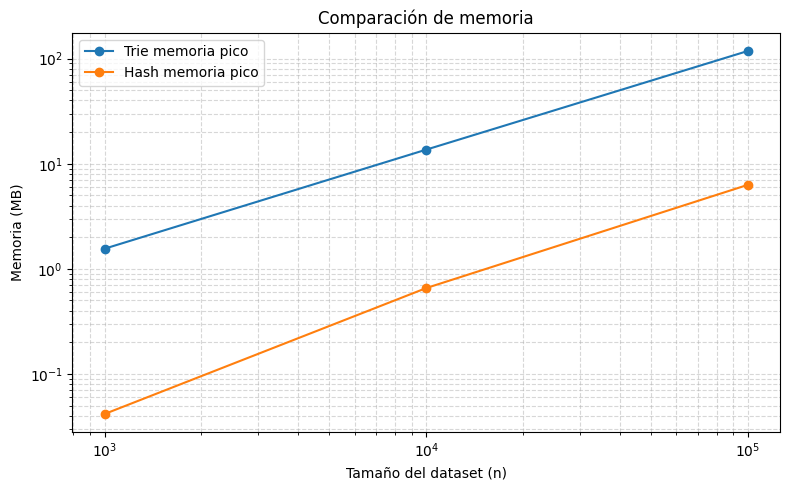

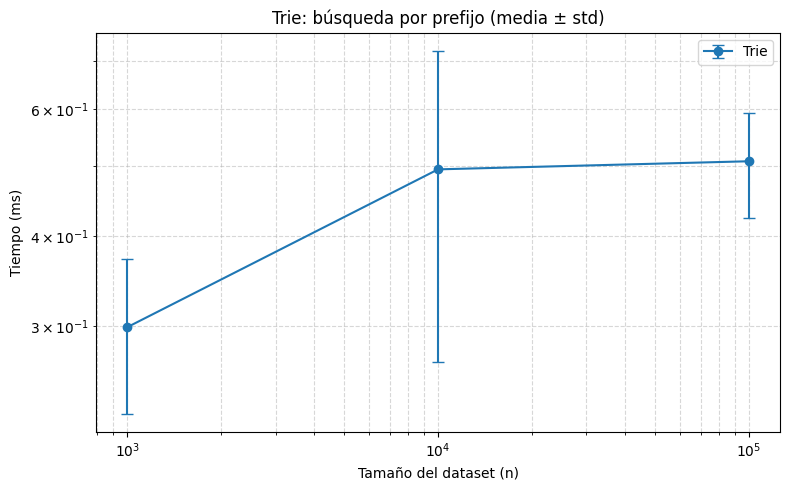

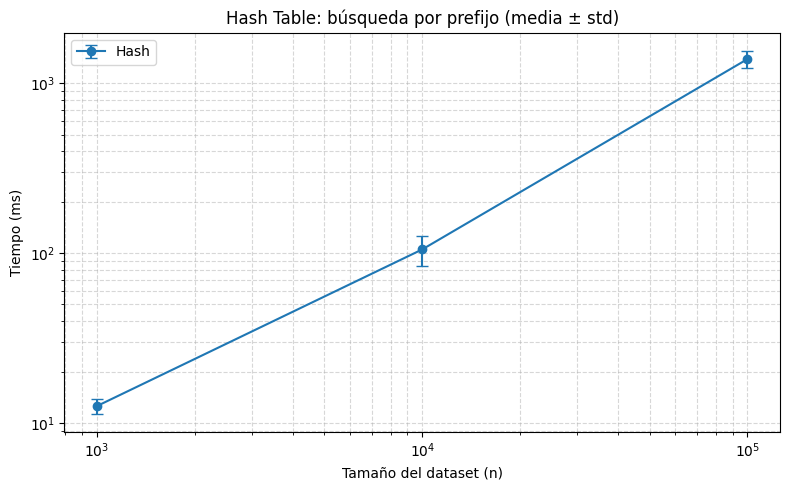


RESUMEN FINAL

Tamaño n = 1000
Trie     | insert: 3.835 ms | exact: 1.130 ms | prefix: 0.299 ms | mem_peak: 1.553 MB
Hash     | insert: 0.078 ms | exact: 0.056 ms | prefix: 12.589 ms | mem_peak: 0.042 MB

Tamaño n = 10000
Trie     | insert: 35.765 ms | exact: 2.132 ms | prefix: 0.495 ms | mem_peak: 13.609 MB
Hash     | insert: 1.163 ms | exact: 0.075 ms | prefix: 105.276 ms | mem_peak: 0.656 MB

Tamaño n = 100000
Trie     | insert: 5529.860 ms | exact: 2.314 ms | prefix: 0.508 ms | mem_peak: 118.190 MB
Hash     | insert: 19.415 ms | exact: 0.280 ms | prefix: 1390.955 ms | mem_peak: 6.292 MB


In [2]:
# ============================================
# EXPERIMENTACIÓN EMPÍRICA: TRIE VS HASH TABLE
# Búsqueda exacta y por prefijo
# Listo para Google Colab
# ============================================

import random
import string
import time
import math
import statistics
import tracemalloc
import matplotlib.pyplot as plt


# =========================================================
# 1. ESTRUCTURAS
# =========================================================

class TrieNode:
    __slots__ = ("children", "is_end")
    def __init__(self):
        self.children = {}
        self.is_end = False


class Trie:
    def __init__(self):
        self.root = TrieNode()

    def insert(self, word: str):
        node = self.root
        for ch in word:
            if ch not in node.children:
                node.children[ch] = TrieNode()
            node = node.children[ch]
        node.is_end = True

    def search(self, word: str) -> bool:
        node = self.root
        for ch in word:
            if ch not in node.children:
                return False
            node = node.children[ch]
        return node.is_end

    def starts_with(self, prefix: str) -> bool:
        node = self.root
        for ch in prefix:
            if ch not in node.children:
                return False
            node = node.children[ch]
        return True


class HashTableWords:
    """
    Hash table simple usando set para búsqueda exacta.
    Para prefijos, se evalúa de forma ingenua recorriendo todas las palabras.
    Esto permite comparar Trie vs Hash Table para búsquedas por prefijo.
    """
    def __init__(self):
        self.words = set()

    def insert(self, word: str):
        self.words.add(word)

    def search(self, word: str) -> bool:
        return word in self.words

    def starts_with(self, prefix: str) -> bool:
        # Búsqueda ingenua por prefijo: O(n * L)
        for w in self.words:
            if w.startswith(prefix):
                return True
        return False


# =========================================================
# 2. GENERACIÓN DE DATASETS
# =========================================================

def random_word(min_len=5, max_len=12):
    length = random.randint(min_len, max_len)
    return ''.join(random.choices(string.ascii_lowercase, k=length))


def generate_unique_words(n, seed=42):
    random.seed(seed)
    words = set()
    while len(words) < n:
        words.add(random_word())
    return list(words)


def sample_existing_queries(words, k=1000, seed=123):
    random.seed(seed)
    k = min(k, len(words))
    return random.sample(words, k)


def sample_prefix_queries(words, k=1000, seed=456):
    random.seed(seed)
    k = min(k, len(words))
    selected = random.sample(words, k)
    prefixes = []
    for w in selected:
        if len(w) <= 2:
            prefixes.append(w[:1])
        else:
            pref_len = random.randint(1, min(4, len(w)))
            prefixes.append(w[:pref_len])
    return prefixes


# =========================================================
# 3. MEDICIÓN DE TIEMPO
# =========================================================

def time_insertion(structure_class, data):
    structure = structure_class()
    t0 = time.perf_counter()
    for x in data:
        structure.insert(x)
    t1 = time.perf_counter()
    return structure, (t1 - t0) * 1000  # ms


def time_exact_search(structure, queries):
    t0 = time.perf_counter()
    for q in queries:
        structure.search(q)
    t1 = time.perf_counter()
    return (t1 - t0) * 1000  # ms


def time_prefix_search(structure, prefixes):
    t0 = time.perf_counter()
    for p in prefixes:
        structure.starts_with(p)
    t1 = time.perf_counter()
    return (t1 - t0) * 1000  # ms


# =========================================================
# 4. MEDICIÓN DE MEMORIA
# =========================================================

def measure_memory(structure_class, data):
    tracemalloc.start()
    structure = structure_class()
    for x in data:
        structure.insert(x)
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return current / 10**6, peak / 10**6  # MB


# =========================================================
# 5. AJUSTE DE CURVAS TEÓRICAS
# =========================================================

def normalize_theoretical_curve(sizes, empirical_times, kind="O(log n)"):
    """
    Escala una curva teórica para que tenga magnitud similar a la empírica.
    """
    if kind == "O(1)":
        base = [1 for _ in sizes]
    elif kind == "O(log n)":
        base = [math.log2(n) for n in sizes]
    elif kind == "O(n)":
        base = [n for n in sizes]
    elif kind == "O(n log n)":
        base = [n * math.log2(n) for n in sizes]
    else:
        raise ValueError("Complejidad no soportada")

    # Escalado simple usando el primer punto no nulo
    scale = empirical_times[0] / base[0] if base[0] != 0 else 1.0
    return [scale * b for b in base]


# =========================================================
# 6. EXPERIMENTO COMPLETO
# =========================================================

def benchmark_structure(
    structure_name,
    structure_class,
    sizes,
    repeats=20,
    query_k=1000,
    seed_base=1000
):
    results = {
        "insert_mean": [],
        "insert_std": [],
        "exact_mean": [],
        "exact_std": [],
        "prefix_mean": [],
        "prefix_std": [],
        "memory_current_mb": [],
        "memory_peak_mb": []
    }

    for idx, n in enumerate(sizes):
        print(f"\n=== {structure_name} | n = {n} ===")

        insert_times = []
        exact_times = []
        prefix_times = []

        # Memoria: solo una vez por tamaño, para no hacer el experimento demasiado pesado
        data_for_memory = generate_unique_words(n, seed=seed_base + idx)
        current_mb, peak_mb = measure_memory(structure_class, data_for_memory)

        for r in range(repeats):
            seed = seed_base + idx * 100 + r
            data = generate_unique_words(n, seed=seed)

            exact_queries = sample_existing_queries(data, k=min(query_k, n), seed=seed + 1)
            prefix_queries = sample_prefix_queries(data, k=min(query_k, n), seed=seed + 2)

            structure, insert_ms = time_insertion(structure_class, data)
            exact_ms = time_exact_search(structure, exact_queries)
            prefix_ms = time_prefix_search(structure, prefix_queries)

            insert_times.append(insert_ms)
            exact_times.append(exact_ms)
            prefix_times.append(prefix_ms)

        results["insert_mean"].append(statistics.mean(insert_times))
        results["insert_std"].append(statistics.stdev(insert_times) if len(insert_times) > 1 else 0.0)

        results["exact_mean"].append(statistics.mean(exact_times))
        results["exact_std"].append(statistics.stdev(exact_times) if len(exact_times) > 1 else 0.0)

        results["prefix_mean"].append(statistics.mean(prefix_times))
        results["prefix_std"].append(statistics.stdev(prefix_times) if len(prefix_times) > 1 else 0.0)

        results["memory_current_mb"].append(current_mb)
        results["memory_peak_mb"].append(peak_mb)

        print(f"Inserción      -> media: {results['insert_mean'][-1]:.3f} ms | std: {results['insert_std'][-1]:.3f}")
        print(f"Búsqueda exacta-> media: {results['exact_mean'][-1]:.3f} ms | std: {results['exact_std'][-1]:.3f}")
        print(f"Búsqueda pref. -> media: {results['prefix_mean'][-1]:.3f} ms | std: {results['prefix_std'][-1]:.3f}")
        print(f"Memoria actual -> {current_mb:.3f} MB")
        print(f"Memoria pico   -> {peak_mb:.3f} MB")

    return results


# =========================================================
# 7. PARÁMETROS
# =========================================================

# Para Colab, empieza así:
sizes = [10**3, 10**4, 10**5]

# Si tu entorno aguanta, luego prueba:
#sizes = [10**3, 10**4, 10**5, 10**6, 10**7]

repeats = 100
# Si necesitas cumplir estrictamente con el enunciado, cambia a:
# repeats = 100
query_k = 1000


# =========================================================
# 8. EJECUTAR EXPERIMENTOS
# =========================================================

trie_results = benchmark_structure(
    structure_name="Trie",
    structure_class=Trie,
    sizes=sizes,
    repeats=repeats,
    query_k=query_k
)

hash_results = benchmark_structure(
    structure_name="HashTable",
    structure_class=HashTableWords,
    sizes=sizes,
    repeats=repeats,
    query_k=query_k
)


# =========================================================
# 9. GRÁFICOS LOG-LOG
# =========================================================

def plot_loglog_with_theory(
    sizes,
    empirical_times,
    title,
    ylabel,
    theory_kind,
    empirical_label
):
    theoretical = normalize_theoretical_curve(sizes, empirical_times, kind=theory_kind)

    plt.figure(figsize=(8, 5))
    plt.loglog(sizes, empirical_times, 'o-', label=empirical_label)
    plt.loglog(sizes, theoretical, '--', label=f'{theory_kind} teórico')
    plt.xlabel('Tamaño del dataset (n)')
    plt.ylabel(ylabel)
    plt.legend()
    plt.title(title)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


# Inserción Trie ~ O(n) total si insertas n palabras de longitud promedio casi constante
plot_loglog_with_theory(
    sizes,
    trie_results["insert_mean"],
    title='Trie: Inserción total',
    ylabel='Tiempo (ms)',
    theory_kind='O(n)',
    empirical_label='Trie empírico'
)

# Búsqueda exacta Trie: para lote fijo de queries, debería ser casi O(1) respecto a n
plot_loglog_with_theory(
    sizes,
    trie_results["exact_mean"],
    title='Trie: Búsqueda exacta',
    ylabel='Tiempo (ms)',
    theory_kind='O(1)',
    empirical_label='Trie empírico'
)

# Búsqueda por prefijo Trie: para lote fijo de prefijos, también casi O(1) respecto a n
plot_loglog_with_theory(
    sizes,
    trie_results["prefix_mean"],
    title='Trie: Búsqueda por prefijo',
    ylabel='Tiempo (ms)',
    theory_kind='O(1)',
    empirical_label='Trie empírico'
)

# Hash table exacta: casi O(1)
plot_loglog_with_theory(
    sizes,
    hash_results["exact_mean"],
    title='Hash Table: Búsqueda exacta',
    ylabel='Tiempo (ms)',
    theory_kind='O(1)',
    empirical_label='Hash empírico'
)

# Hash table para prefijo ingenuo: aproximadamente O(n)
plot_loglog_with_theory(
    sizes,
    hash_results["prefix_mean"],
    title='Hash Table: Búsqueda por prefijo',
    ylabel='Tiempo (ms)',
    theory_kind='O(n)',
    empirical_label='Hash empírico'
)


# =========================================================
# 10. COMPARACIÓN DIRECTA TRIE VS HASH
# =========================================================

plt.figure(figsize=(8, 5))
plt.loglog(sizes, trie_results["prefix_mean"], 'o-', label='Trie prefijo')
plt.loglog(sizes, hash_results["prefix_mean"], 'o-', label='Hash prefijo')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Tiempo (ms)')
plt.title('Comparación: búsqueda por prefijo')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.loglog(sizes, trie_results["insert_mean"], 'o-', label='Trie inserción')
plt.loglog(sizes, hash_results["insert_mean"], 'o-', label='Hash inserción')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Tiempo (ms)')
plt.title('Comparación: inserción')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.loglog(sizes, trie_results["memory_peak_mb"], 'o-', label='Trie memoria pico')
plt.loglog(sizes, hash_results["memory_peak_mb"], 'o-', label='Hash memoria pico')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Memoria (MB)')
plt.title('Comparación de memoria')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


# =========================================================
# 11. BARRAS DE ERROR
# =========================================================

def plot_error_bars(sizes, means, stds, title, ylabel, label):
    plt.figure(figsize=(8, 5))
    plt.errorbar(sizes, means, yerr=stds, fmt='o-', capsize=4, label=label)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Tamaño del dataset (n)')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


plot_error_bars(
    sizes,
    trie_results["prefix_mean"],
    trie_results["prefix_std"],
    title='Trie: búsqueda por prefijo (media ± std)',
    ylabel='Tiempo (ms)',
    label='Trie'
)

plot_error_bars(
    sizes,
    hash_results["prefix_mean"],
    hash_results["prefix_std"],
    title='Hash Table: búsqueda por prefijo (media ± std)',
    ylabel='Tiempo (ms)',
    label='Hash'
)


# =========================================================
# 12. RESUMEN EN TEXTO
# =========================================================

print("\n" + "=" * 80)
print("RESUMEN FINAL")
print("=" * 80)

for i, n in enumerate(sizes):
    print(f"\nTamaño n = {n}")
    print(f"Trie     | insert: {trie_results['insert_mean'][i]:.3f} ms | "
          f"exact: {trie_results['exact_mean'][i]:.3f} ms | "
          f"prefix: {trie_results['prefix_mean'][i]:.3f} ms | "
          f"mem_peak: {trie_results['memory_peak_mb'][i]:.3f} MB")

    print(f"Hash     | insert: {hash_results['insert_mean'][i]:.3f} ms | "
          f"exact: {hash_results['exact_mean'][i]:.3f} ms | "
          f"prefix: {hash_results['prefix_mean'][i]:.3f} ms | "
          f"mem_peak: {hash_results['memory_peak_mb'][i]:.3f} MB")